In [ ]:
# Cell 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Upload Telco-Customer-Churn.csv

uploaded = files.upload()

print("File uploaded successfully!")

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv
File uploaded successfully!


In [ ]:
# Cell 3: Read the CSV file

df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Number of rows: 7043
Number of columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cell 4: Basic information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cell 5: Data quality check

print("Missing values in each column:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset information:")
df.info()

Missing values in each column:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [ ]:
# Cell 6: Data cleaning

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values after conversion
print("Missing TotalCharges values:")
print(df["TotalCharges"].isnull().sum())

# Fill missing TotalCharges using 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Remove duplicate customer records
df = df.drop_duplicates()

print("\nDataset after cleaning:")
print(df.shape)

display(df.head())

Missing TotalCharges values:
11

Dataset after cleaning:
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cell 7: Churn distribution

churn_counts = df["Churn"].value_counts()

print("Customer Churn Counts:")
display(churn_counts)

print("\nCustomer Churn Percentage:")
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
display(churn_percentage.round(2))

Customer Churn Counts:


,count
Churn,
No,5174
Yes,1869



Customer Churn Percentage:


,proportion
Churn,
No,73.46
Yes,26.54


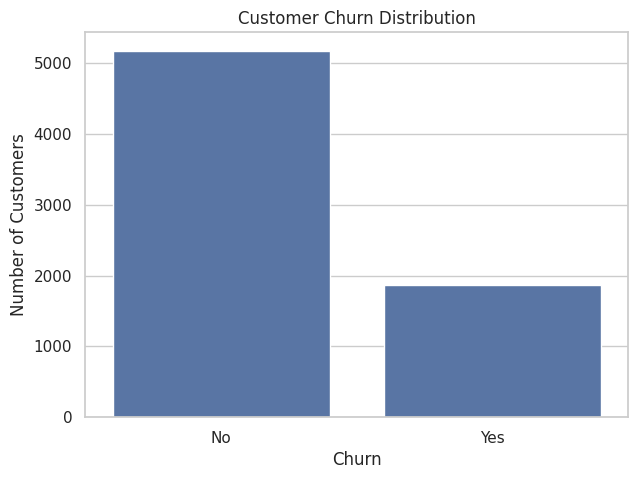

In [ ]:
# Cell 8: Churn visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Cell 9: Overall churn rate

total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Active Customers:", total_customers - churned_customers)
print("Overall Churn Rate: {:.2f}%".format(churn_rate))

Total Customers: 7043
Churned Customers: 1869
Active Customers: 5174
Overall Churn Rate: 26.54%


In [ ]:
# Cell 10: Churn by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract:")
display(contract_churn.round(2))

Churn percentage by contract:


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


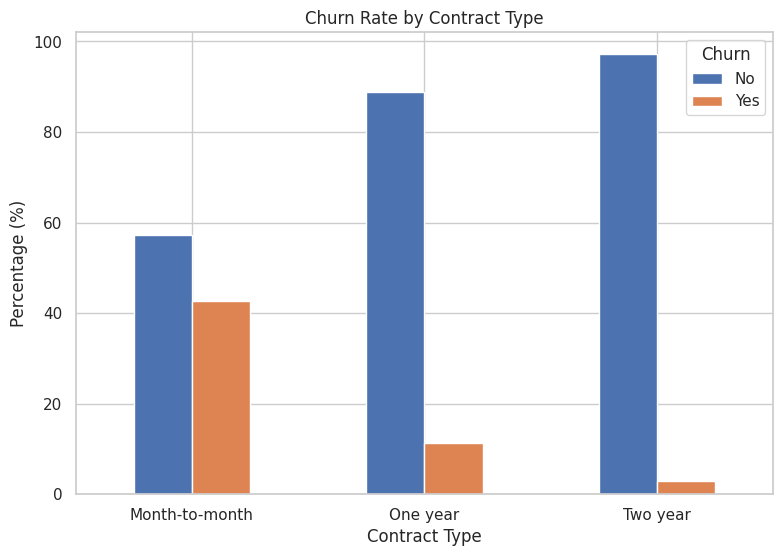

In [ ]:
# Cell 11: Visualize churn by contract

contract_churn_plot = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Cell 12: Churn by tenure

tenure_churn = df.groupby("Churn")["tenure"].mean()

print("Average tenure by churn status:")
display(tenure_churn)

Average tenure by churn status:


,tenure
Churn,
No,37.569965
Yes,17.979133


In [ ]:
# Cell 13: Create tenure cohorts

def tenure_group(tenure):
    if tenure <= 6:
        return "0-6 Months"
    elif tenure <= 12:
        return "7-12 Months"
    elif tenure <= 24:
        return "13-24 Months"
    elif tenure <= 48:
        return "25-48 Months"
    else:
        return "49+ Months"

df["Tenure_Cohort"] = df["tenure"].apply(tenure_group)

print("Tenure cohorts created!")

display(
    df["Tenure_Cohort"].value_counts()
)

Tenure cohorts created!


,count
Tenure_Cohort,
49+ Months,2239
25-48 Months,1594
0-6 Months,1481
13-24 Months,1024
7-12 Months,705


In [ ]:
# Cell 14: Churn rate by customer cohort

cohort_churn = pd.crosstab(
    df["Tenure_Cohort"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by tenure cohort:")

display(cohort_churn.round(2))

Churn percentage by tenure cohort:


Churn,No,Yes
Tenure_Cohort,,
0-6 Months,47.06,52.94
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49+ Months,90.49,9.51
7-12 Months,64.11,35.89


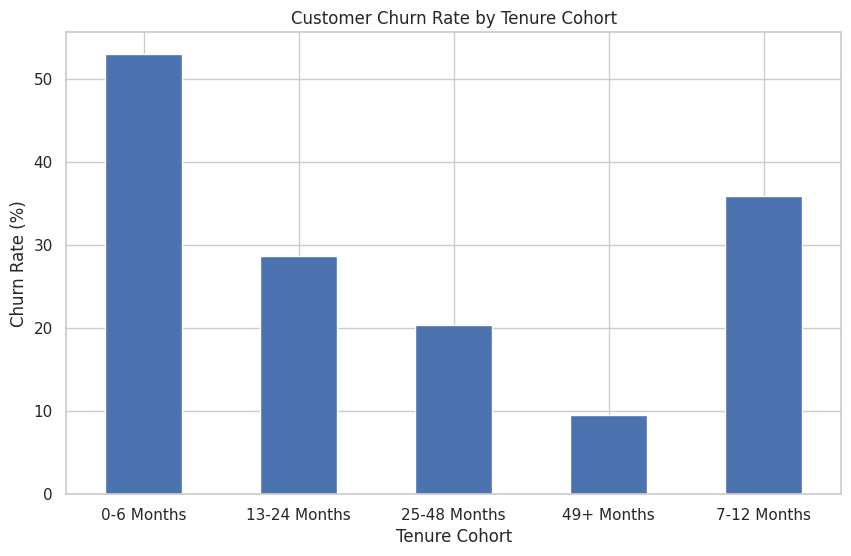

In [ ]:
# Cell 15: Visualize cohort churn

cohort_churn_plot = cohort_churn["Yes"]

plt.figure(figsize=(10, 6))

cohort_churn_plot.plot(
    kind="bar"
)

plt.title("Customer Churn Rate by Tenure Cohort")
plt.xlabel("Tenure Cohort")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Cell 16: Monthly charges analysis

monthly_charges = df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)

print("Monthly Charges by Churn Status:")

display(monthly_charges.round(2))

Monthly Charges by Churn Status:


,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


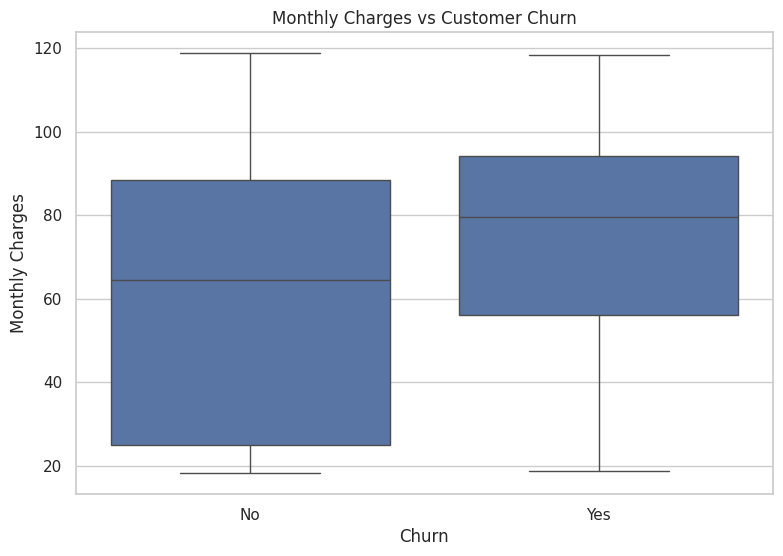

In [ ]:
# Cell 17: Monthly charges distribution

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
# Cell 18: Customer lifetime analysis

df["Estimated_Lifetime_Value"] = (
    df["MonthlyCharges"] * df["tenure"]
)

print("Customer Lifetime Value statistics:")

display(
    df.groupby("Churn")["Estimated_Lifetime_Value"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

Customer Lifetime Value statistics:


,mean,median,min,max
Churn,,,,
No,2549.77,1687.12,0.00,8550.0
Yes,1531.61,700.00,18.85,8481.6


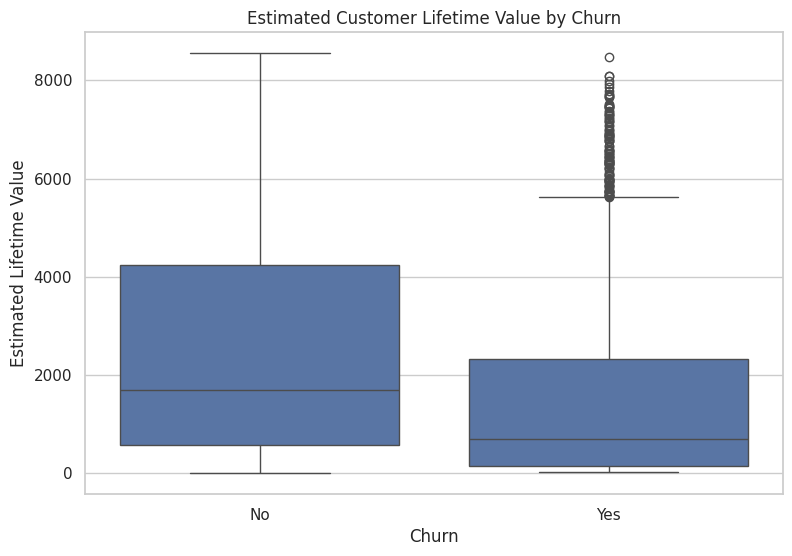

In [ ]:
# Cell 19: Lifetime value visualization

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="Estimated_Lifetime_Value"
)

plt.title("Estimated Customer Lifetime Value by Churn")
plt.xlabel("Churn")
plt.ylabel("Estimated Lifetime Value")

plt.show()

In [ ]:
# Cell 20: Churn by payment method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn rate by payment method:")

display(payment_churn.round(2))

Churn rate by payment method:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11
